In [8]:
import pandas as pd
import numpy as np

# קליטת הקובץ
file_path = 'listings.csv'

# טעינת הדאטה
df = pd.read_csv(file_path)

###############

# הסרת שורות שבהן כל הערכים ריקים
df_clean = df.dropna(how='all').copy()

print(f"Shape after dropping empty rows: {df_clean.shape}")

###############

# פונקציה לניקוי המחיר והמרה למספר
def clean_price(value):
    if pd.isna(value):
        return np.nan
    # המרה למחרוזת, הסרת כל תו שאינו מספר (כמו ₪, פסיקים, רווחים)
    clean_val = str(value).replace(',', '').replace('₪', '').replace(' ', '').strip()
    # ניסיון המרה למספר
    try:
        return float(clean_val)
    except ValueError:
        return np.nan

# החלת הניקוי
df_clean['price'] = df_clean['price'].apply(clean_price)

###############

# סינון מחירים בטווח 400,000 עד 7,000,000 והסרת ערכים חסרים
df_clean = df_clean[
    (df_clean['price'] >= 400000) &
    (df_clean['price'] <= 7000000) &
    (df_clean['price'].notna())
]

# המרה למספרים שלמים (ללא נקודה עשרונית)
df_clean['price'] = df_clean['price'].astype(int)

print(f"Shape after price filter: {df_clean.shape}")
print(df_clean['price'].head())

##############

# המרה של שדה המ"ר למספרי (מטפל במקרים של טקסט בטעות)
df_clean['square_meters'] = pd.to_numeric(df_clean['square_meters'], errors='coerce')

# סינון: גודל בין 25 ל-1000
df_clean = df_clean[
    (df_clean['square_meters'] >= 25) &
    (df_clean['square_meters'] <= 1000)
]

print(f"Shape after sq meter filter: {df_clean.shape}")


###################################

# חישוב מחיר למטר והמרה למספר שלם
df_clean['price_per_meter'] = (df_clean['price'] / df_clean['square_meters']).astype(int)

print(df_clean[['price', 'square_meters', 'price_per_meter']].head())

###############################

def classify_media(row):
    # בדיקה האם יש תמונות (גדול מ-0 ולא NaN)
    has_images = pd.notna(row['images_count']) and row['images_count'] > 0

    # בדיקה האם יש וידאו (באחד משני השדות)
    has_video = (pd.notna(row['mp4_video_url']) and str(row['mp4_video_url']).strip() != '') or \
                (pd.notna(row['video_url']) and str(row['video_url']).strip() != '')

    if has_images and has_video:
        return 'גם תמונות וגם וידאו'
    elif has_images:
        return 'רק תמונות'
    elif has_video:
        return 'רק וידיאו'
    else:
        return 'ללא מדיה'

# הפעלת הפונקציה על כל שורה (axis=1)
df_clean['media_type'] = df_clean.apply(classify_media, axis=1)

##########################

# 1. יצירת מילון מיפוי בין קוד שכונה לשם שכונה מתוך הרשומות המלאות
hood_mapping = df_clean.dropna(subset=['neighborhood']).set_index('hood_id')['neighborhood'].to_dict()

# 2. פונקציה למילוי הערך החסר
def fill_neighborhood(row):
    # אם השם קיים, נשאיר אותו
    if pd.notna(row['neighborhood']):
        return row['neighborhood']
    # אחרת, ננסה למצוא לפי ה-id
    return hood_mapping.get(row['hood_id'], row['neighborhood']) # אם לא נמצא, נשאר NaN

# ביצוע ההשלמה
df_clean['neighborhood'] = df_clean.apply(fill_neighborhood, axis=1)

#####################

# רשימת ערכים להסרה
types_to_remove = [
    "מגרשים",
    "בית פרטי/ קוטג'",
    "דו משפחתי",
    "כללי",
    "חניה"
]

# סינון - משאירים רק את מה ש*לא* ברשימה הזו
df_clean = df_clean[~df_clean['HomeTypeID_text'].isin(types_to_remove)]

print("Home Types remaining:")
print(df_clean['HomeTypeID_text'].unique())
print(f"Final shape: {df_clean.shape}")

####################

Shape after dropping empty rows: (3647, 52)
Shape after price filter: (3427, 52)
0     599000
1    1890000
2    1030000
3     990000
4    1350000
Name: price, dtype: int64
Shape after sq meter filter: (3417, 52)
     price  square_meters  price_per_meter
0   599000          987.0              606
1  1890000          177.0            10677
2  1030000           90.0            11444
3   990000           76.0            13026
4  1350000           94.0            14361
Home Types remaining:
<StringArray>
['דירה', 'גג/ פנטהאוז', 'דירת גן', 'דופלקס', 'יחידת דיור', 'טריפלקס']
Length: 6, dtype: str
Final shape: (2896, 54)


In [9]:
import plotly.express as px
import ast
import numpy as np

# --- חילוץ קורדינאטות  ---

if 'lat' not in df_clean.columns or 'lon' not in df_clean.columns:
    def parse_coordinates_dict(coord_str):
        try:
            if pd.isna(coord_str):
                return np.nan, np.nan
            coord_dict = ast.literal_eval(str(coord_str))
            lat = coord_dict.get('latitude')
            lon = coord_dict.get('longitude')
            return float(lat), float(lon)
        except:
            return np.nan, np.nan

    df_clean['lat'], df_clean['lon'] = zip(*df_clean['coordinates'].apply(parse_coordinates_dict))

# סינון שורות ללא מיקום תקין
df_map = df_clean.dropna(subset=['lat', 'lon']).copy()

# --- חישוב גבולות צבע חכמים (אחוזונים 5 ו-95) ---

p5_ppm = df_map['price_per_meter'].quantile(0.05)
p95_ppm = df_map['price_per_meter'].quantile(0.95)


# ---  Carto Voyager + סקאלת כחולים
fig_voyager = px.scatter_mapbox(
    df_map,
    lat="lat",
    lon="lon",
    color="price_per_meter",
    color_continuous_scale=[
        [0.0, "rgb(130, 200, 255)"],
        [1.0, "rgb(0, 0, 150)"]
    ],
    range_color=[p5_ppm, p95_ppm],
    opacity=0.7,
    hover_data={'neighborhood': True, 'square_meters': True, 'price_per_meter': ':.0f', 'lat': False, 'lon': False},
    zoom=12,
    height=600,
    width=600,
    title="מפת נכסים - סגנון Voyager (צבעי פסטל) + סקאלת כחולים"
)

fig_voyager.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[
        {
            "below": 'traces',
            "sourcetype": "raster",
            "sourceattribution": "CartoDB Voyager",
            "source": [
                "https://basemaps.cartocdn.com/rastertiles/voyager/{z}/{x}/{y}{r}.png"
            ]
        }
    ],
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig_voyager.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_3188\1450865674.py:31: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [10]:
import plotly.express as px
import pandas as pd

# 1. סינון ראשוני: מינימום 15 נכסים בשכונה
min_listings = 15
neighborhood_counts = df_map['neighborhood'].value_counts()
valid_neighborhoods_initial = neighborhood_counts[neighborhood_counts >= min_listings].index
df_temp = df_map[df_map['neighborhood'].isin(valid_neighborhoods_initial)].copy()

# 2. חישוב חציון ומיון (מהזול ליקר)
median_prices = df_temp.groupby('neighborhood')['price'].median().sort_values()

# 3. בחירת ה-Top 5 וה-Bottom 5
if len(median_prices) > 10:
    bottom_5 = median_prices.head(5).index.tolist()
    top_5 = median_prices.tail(5).index.tolist()
    selected_neighborhoods = bottom_5 + top_5
else:
    selected_neighborhoods = median_prices.index.tolist()

# זה מוריד את עסקאות הקיצון שמותחות את הגרף
filtered_dfs = []
for hood in selected_neighborhoods:
    subset = df_temp[df_temp['neighborhood'] == hood]
    p05 = subset['price'].quantile(0.05) # גבול תחתון
    p95 = subset['price'].quantile(0.95) # גבול עליון
    clean_subset = subset[(subset['price'] >= p05) & (subset['price'] <= p95)]
    filtered_dfs.append(clean_subset)

# איחוד הנתונים הנקיים חזרה לדאטה-פריים אחד
df_ridge_clean = pd.concat(filtered_dfs)

print(f"יוצר גרף Ridge נקי (ללא קיצון) עבור {len(selected_neighborhoods)} שכונות")

# --- יצירת גרף Ridgeline ---
fig_ridge = px.violin(
    df_ridge_clean,
    x='price',
    y='neighborhood',
    color='neighborhood',
    orientation='h',
    title='התפלגות מחירים לפי שכונות (ללא עסקאות קיצון)',
    labels={'neighborhood': 'שכונה', 'price': 'מחיר בש"ח'},
    category_orders={'neighborhood': selected_neighborhoods},
    color_discrete_sequence=px.colors.qualitative.Prism,
    box=False,
    points=False
)

# --- עיצוב ה-Ridge ---
fig_ridge.update_traces(
    side='positive',
    width=2.5,
    meanline_visible=True,
    line=dict(color='DarkSlateGrey', width=1.5),
    opacity=0.8

)

fig_ridge.update_layout(
    template="plotly_white",
    showlegend=False,
    xaxis_tickformat = ',.0f',
    height=700,
    violinmode='overlay',
    yaxis=dict(
        showgrid=True,
        title=None,
        tickfont=dict(size=12)
    ),
    xaxis=dict(
        title="מחיר נכס (₪)",
        zeroline=False
    ),
    margin=dict(l=150, t=60, b=50, r=50)
)

fig_ridge.show()

יוצר גרף Ridge נקי (ללא קיצון) עבור 10 שכונות


יוצר גרף Ridge נקי (ללא קיצון) עבור 10 שכונות


In [11]:
import plotly.express as px
import numpy as np
import pandas as pd

# 1. עיבוד וניקוי
df_rooms = df_map.copy()
df_rooms = df_rooms.dropna(subset=['line_1'])
df_rooms['rooms_extracted'] = df_rooms['line_1'].astype(str).str.extract(r'(\d+(?:\.\d+)?)').astype(float)
df_rooms['rooms_clean'] = np.floor(df_rooms['rooms_extracted'])
df_rooms = df_rooms[df_rooms['rooms_clean'].isin([2, 3, 4, 5])]

# 2. סינון שכונות
neighborhood_counts = df_rooms['neighborhood'].value_counts()
valid_hoods = neighborhood_counts[neighborhood_counts >= 20].index
df_filtered = df_rooms[df_rooms['neighborhood'].isin(valid_hoods)].copy()

# 3. חישוב אחוזים
df_counts = df_filtered.groupby(['neighborhood', 'rooms_clean']).size().reset_index(name='count')
total_per_hood = df_counts.groupby('neighborhood')['count'].transform('sum')
df_counts['percentage'] = (df_counts['count'] / total_per_hood) * 100

# --- לוגיקה להסתרת טקסט ---
# אם האחוז קטן מ-6%, הטקסט יהיה ריק. אחרת, הוא יהיה המספר עם %
df_counts['label_text'] = df_counts.apply(
    lambda row: f"{int(round(row['percentage']))}%" if row['percentage'] >= 6 else "",
    axis=1
)

df_counts['rooms_label'] = df_counts['rooms_clean'].astype(int).astype(str) + " חדרים"

# 4. מיון
small_apts_share = df_counts[df_counts['rooms_clean'].isin([2, 3])].groupby('neighborhood')['percentage'].sum()
sorted_neighborhoods = small_apts_share.sort_values(ascending=False).index.tolist()
remaining_hoods = [h for h in valid_hoods if h not in sorted_neighborhoods]
sorted_neighborhoods.extend(remaining_hoods)

# --- הגדרת צבעים פסטליים ---
pastel_colors = {
    "2 חדרים": "#BFD7ED", # תכלת פסטל בהיר מאוד
    "3 חדרים": "#96C0CE", # תכלת אפרפר
    "4 חדרים": "#60A3D9", # תכלת בינוני רך
    "5 חדרים": "#0074B7"  # כחול רך אך ברור
}

# 5. יצירת הגרף
fig_stack = px.bar(
    df_counts,
    x="neighborhood",
    y="percentage",
    color="rooms_label",
    text="label_text",
    title="התפלגות גודל דירות בשכונות (2-5 חדרים)",
    labels={"neighborhood": "שכונה", "percentage": "אחוז מסך הנכסים", "rooms_label": ""},

    category_orders={
        "neighborhood": sorted_neighborhoods,
        "rooms_label": ["2 חדרים", "3 חדרים", "4 חדרים", "5 חדרים"]
    },

    color_discrete_map=pastel_colors
)

# --- עיצוב ---
fig_stack.update_layout(
    template="plotly_white",
    height=600,
    bargap=0.2,

    yaxis=dict(
        title="אחוז מהנכסים (%)",
        ticksuffix="%",
        showgrid=True,
        gridcolor='#F0F0F0', # גריד אפור בהיר מאוד ועדין
        zeroline=False
    ),

    xaxis=dict(
        title=None,
        tickangle=-45
    ),

    # מיקום המקרא למעלה
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1,
        title=None
    ),

    margin=dict(t=80, b=100),
    font=dict(family="Arial", size=12)
)

fig_stack.update_traces(
    textposition='inside',
    textfont=dict(size=13, color='white', family="Arial"),
    marker_line_color='white',
    marker_line_width=0.5,
    insidetextanchor='middle'
)

fig_stack.show()

In [12]:
import plotly.express as px
import pandas as pd
import numpy as np
import statsmodels.api as sm # נדרש עבור חישוב קו המגמה (ols)

# 1. הכנת הנתונים
df_analysis = df_map.copy()
if 'rooms_clean' not in df_analysis.columns:
    df_analysis['rooms_extracted'] = df_analysis['line_1'].astype(str).str.extract(r'(\d+(?:\.\d+)?)').astype(float)
    df_analysis['rooms_clean'] = np.floor(df_analysis['rooms_extracted'])

df_analysis = df_analysis[
    (df_analysis['price'] > 500000) &
    (df_analysis['price'] < 5000000) &
    (df_analysis['rooms_clean'].between(2, 6))
]

# סינון וחישוב חציונים
df_trend = df_analysis[df_analysis['images_count'] <= 16]
trend_data = df_trend.groupby('images_count')['price'].median().reset_index()

# 2. יצירת הגרף המשופר
fig_price = px.scatter(
    trend_data,
    x='images_count',
    y='price',
    trendline="ols", # קו מגמה לינארי
    trendline_color_override="black", # צבע בולט לקו המגמה
    title="הקשר בין השקעה בנראות (מספר תמונות) למחיר הנכס",
    labels={'images_count': 'מספר תמונות במודעה', 'price': 'מחיר חציוני (₪)'}
)

# 3. עיצוב הנראות
fig_price.update_traces(
    marker=dict(
        size=12,
        color='RoyalBlue',
    ),
    selector=dict(mode='markers') # מחיל את העיצוב רק על הנקודות ולא על הקו
)

# עיצוב מיוחד לקו המגמה
fig_price.data[1].line.dash = 'dash'
fig_price.data[1].line.width = 3

fig_price.update_layout(
    template="plotly_white",
    height=600,

    # עיצוב ציר ה-Y (מחיר)
    yaxis=dict(
        tickformat=',.0f', # פסיקים באלפים
        title_font=dict(size=14),
        showgrid=True,
        gridcolor='#F0F0F0'
    ),

    xaxis=dict(
        tickmode='linear', # מכריח את הציר להציג כל מספר
        dtick=1,           # קפיצות של 1 בדיוק
        showgrid=False,
        title_font=dict(size=14)
    ),

    # כותרת
    title=dict(
        font=dict(size=20),
        x=0.5, # מירכוז כותרת
        xanchor='center'
    ),

    # הוספת הסבר מרחף (Tooltip) נקי
    hovermode="x unified"
)

fig_price.show()

In [13]:
import plotly.express as px
import pandas as pd
import numpy as np

# 1. חישוב מחיר "מצופה" (Baseline)

base_prices = df_analysis.groupby(['neighborhood', 'rooms_clean'])['price'].mean().reset_index()
base_prices.rename(columns={'price': 'expected_price'}, inplace=True)

df_premium = df_analysis.merge(base_prices, on=['neighborhood', 'rooms_clean'], how='left')
df_premium['price_premium_percent'] = ((df_premium['price'] - df_premium['expected_price']) / df_premium['expected_price']) * 100

premium_trend = df_premium.groupby('images_count')['price_premium_percent'].mean().reset_index()
premium_trend_filtered = premium_trend[premium_trend['images_count'] <= 15].copy()

pastel_diverging = ["#EF5350", "#F5F5F5", "#66BB6A"]

# 2. הכנת טקסט להצגה (עם סימן %)
premium_trend_filtered['label_text'] = premium_trend_filtered['price_premium_percent'].apply(lambda x: f"{x:+.1f}%")

# 3. יצירת הגרף המשופר
fig_premium = px.bar(
    premium_trend_filtered,
    x='images_count',
    y='price_premium_percent',
    title='כמה שווה תמונה? הפער מהמחיר הממוצע בשכונה',
    labels={'images_count': 'מספר תמונות במודעה', 'price_premium_percent': 'סטייה מהמחיר הממוצע (%)'},

    # צביעה לפי הערך
    color='price_premium_percent',

    # סקאלת צבעים: אדום (שלילי) -> צהוב (אפס) -> ירוק (חיובי)
    color_continuous_scale=pastel_diverging,
    color_continuous_midpoint=0,

    text='label_text'
)

# 4. עיצוב ושיפורים ויזואליים
fig_premium.update_traces(
    textposition='outside', # הטקסט מעל/מתחת לבר ולא בתוכו
    marker_line_color='black', # מסגרת דקה לכל בר
    marker_line_width=1,
    textfont_size=12
)

fig_premium.update_layout(
    template="plotly_white",
    height=550,

    # הסתרת בר הצבעים בצד (כי הצבעים אינטואיטיביים)
    coloraxis_showscale=False,

    yaxis=dict(
        title="סטייה באחוזים מהמחיר הממוצע",
        ticksuffix="%", # מוסיף % לציר עצמו
        showgrid=True,
        gridcolor='#E0E0E0',
        zeroline=True,      # קו האפס המובנה של פלוטלי
        zerolinecolor='black', # צבע קו האפס
        zerolinewidth=2     # עובי קו האפס
    ),

    xaxis=dict(
        title="מספר תמונות",
        tickmode='linear', # מספרים שלמים בלבד
        dtick=1,
        showgrid=False
    ),

    # הרחבת הטווח בציר ה-Y כדי שהטקסט (outside) לא ייחתך
    margin=dict(t=80, b=50)
)

fig_premium.add_annotation(
    x=2, y=premium_trend_filtered['price_premium_percent'].min(),
    text="מתחת לממוצע", showarrow=False, yshift=-20, font=dict(color="red")
)
fig_premium.add_annotation(
    x=13, y=premium_trend_filtered['price_premium_percent'].max(),
    text="מעל הממוצע", showarrow=False, yshift=20, font=dict(color="green")
)

fig_premium.show()

## השוואת אוצר מילים בין נכסים זולים ליקרים

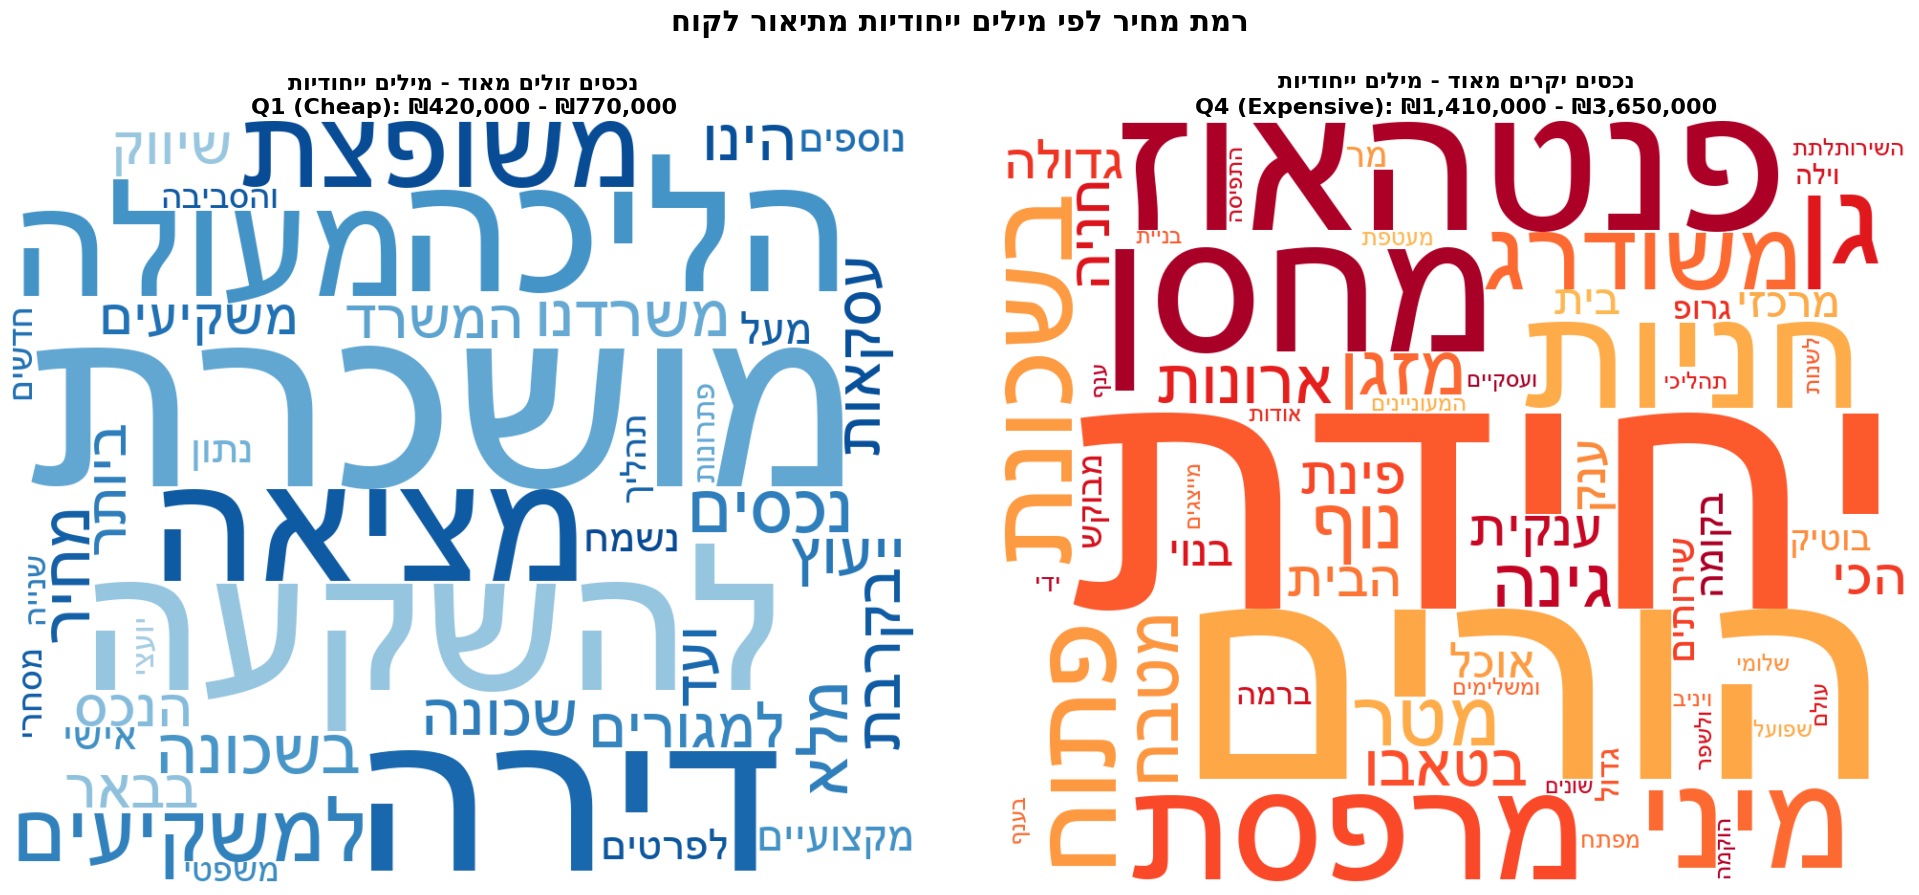

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import chi2_contingency

# שימוש בנתונים שכבר נוקו בשלבים הקודמים
text_df = df_clean.dropna(subset=['search_text', 'price']).copy()

# חילוץ תיאור לקוח
def extract_description(text):
    if pd.isna(text):
        return None
    match = re.search(r'תאור לקוח[:\s]+(.*)', str(text), re.DOTALL)
    return match.group(1).strip() if match else None

text_df['description'] = text_df['search_text'].apply(extract_description)
text_df = text_df.dropna(subset=['description']).copy()
text_df['description_clean'] = text_df['description'].str.strip()
text_df = text_df[text_df['description_clean'] != ""].copy()

# חלוקה לרבעונים כמו temp.py
text_df['price_quartile'] = pd.qcut(
    text_df['price'],
    q=4,
    labels=['Q1 (Cheap)', 'Q2', 'Q3', 'Q4 (Expensive)']
)

q1_data = text_df[text_df['price_quartile'] == 'Q1 (Cheap)'].copy()
q4_data = text_df[text_df['price_quartile'] == 'Q4 (Expensive)'].copy()

# סטופ-וורדס כמו temp.py
def get_hebrew_stopwords():
    return set([
        'של', 'את', 'ה', 'על', 'עם', 'זה', 'זו', 'אני', 'הוא', 'היא',
        'כל', 'או', 'גם', 'יש', 'לא', 'אם', 'כי', 'מה', 'שום', 'כמו',
        'בבית', 'ממש', 'יותר', 'רק', 'עוד', 'הם', 'זאת', 'כך', 'מאוד',
        'הזה', 'הזאת', 'ללא', 'כאן', 'היום', 'ב', 'מ', 'ל', 'כ', 'ש'
    ])

# לוגיקה זהה ל-temp.py לבחירת מילים מבדילות
def calculate_distinctive_words(q1_df, q4_df, top_n=60):
    all_text = pd.concat([q1_df['description_clean'], q4_df['description_clean']])
    stopwords = get_hebrew_stopwords()

    vectorizer = TfidfVectorizer(
        max_features=200,
        min_df=2,
        max_df=0.7,
        token_pattern=r'[א-ת]{2,}'
    )

    vectorizer.fit(all_text)
    q1_tfidf = vectorizer.transform(q1_df['description_clean'])
    q4_tfidf = vectorizer.transform(q4_df['description_clean'])

    feature_names = vectorizer.get_feature_names_out()
    q1_freq = np.asarray(q1_tfidf.sum(axis=0)).flatten()
    q4_freq = np.asarray(q4_tfidf.sum(axis=0)).flatten()
    q1_doc_freq = np.asarray((q1_tfidf > 0).sum(axis=0)).flatten()
    q4_doc_freq = np.asarray((q4_tfidf > 0).sum(axis=0)).flatten()

    rows = []
    for i, word in enumerate(feature_names):
        if word in stopwords:
            continue

        contingency = [
            [q1_doc_freq[i], len(q1_df) - q1_doc_freq[i]],
            [q4_doc_freq[i], len(q4_df) - q4_doc_freq[i]]
        ]

        try:
            chi2, p_value, _, _ = chi2_contingency(contingency)
            rows.append({
                'word': word,
                'q1_tfidf': q1_freq[i],
                'q4_tfidf': q4_freq[i],
                'q1_docs': q1_doc_freq[i],
                'q4_docs': q4_doc_freq[i],
                'chi2': chi2,
                'p_value': p_value,
                'ratio_q1': q1_doc_freq[i] / (q4_doc_freq[i] + 1),
                'ratio_q4': q4_doc_freq[i] / (q1_doc_freq[i] + 1)
            })
        except Exception:
            continue

    chi2_df = pd.DataFrame(rows)
    if chi2_df.empty:
        return pd.DataFrame(columns=['word', 'q1_tfidf', 'ratio_q1']), pd.DataFrame(columns=['word', 'q4_tfidf', 'ratio_q4'])

    q1_distinctive = chi2_df[
        (chi2_df['ratio_q1'] > 1.5) &
        (chi2_df['p_value'] < 0.05) &
        (chi2_df['q1_docs'] >= 3)
    ].nlargest(top_n, 'ratio_q1')

    q4_distinctive = chi2_df[
        (chi2_df['ratio_q4'] > 1.5) &
        (chi2_df['p_value'] < 0.05) &
        (chi2_df['q4_docs'] >= 3)
    ].nlargest(top_n, 'ratio_q4')

    return q1_distinctive, q4_distinctive

q1_dist, q4_dist = calculate_distinctive_words(q1_data, q4_data, top_n=60)

manual_duplicate_map = {
    'הדירה': 'דירה'
}

def map_duplicate_forms(word):
    token = str(word).strip()
    return manual_duplicate_map.get(token, token)

def build_wordcloud_weights(dist_df, tfidf_col, ratio_col):
    merged_weights = {}
    for _, row in dist_df.iterrows():
        canonical = map_duplicate_forms(row['word'])
        weight = float(row[tfidf_col]) * float(row[ratio_col])
        merged_weights[canonical] = merged_weights.get(canonical, 0.0) + weight
    return {word[::-1]: score for word, score in merged_weights.items()}

# יצירת ענני מילים מהמשקלים (tfidf * ratio) אחרי מיזוג כפילויות
q1_words = build_wordcloud_weights(q1_dist, 'q1_tfidf', 'ratio_q1')
q4_words = build_wordcloud_weights(q4_dist, 'q4_tfidf', 'ratio_q4')

q1_cmap = plt.get_cmap('Blues')
q4_cmap = plt.get_cmap('YlOrRd')

def q1_color_func(*args, **kwargs):
    shade = np.random.uniform(0.35, 0.90)
    r, g, b, _ = q1_cmap(shade)
    return f"rgb({int(r * 255)}, {int(g * 255)}, {int(b * 255)})"

def q4_color_func(*args, **kwargs):
    shade = np.random.uniform(0.35, 0.92)
    r, g, b, _ = q4_cmap(shade)
    return f"rgb({int(r * 255)}, {int(g * 255)}, {int(b * 255)})"

def format_price_range(min_price, max_price):
    return f"₪{int(min_price):,} - ₪{int(max_price):,}"

q1_range_label = format_price_range(q1_data['price'].min(), q1_data['price'].max())
q4_range_label = format_price_range(q4_data['price'].min(), q4_data['price'].max())

plt.figure(figsize=(20, 9))

plt.subplot(1, 2, 1)
if q4_words:
    wc_q4 = WordCloud(
        width=950,
        height=800,
        background_color='white',
        font_path='C:/Windows/Fonts/Arial.ttf',
        colormap='YlOrRd',
        color_func=q4_color_func,
        relative_scaling=0.5,
        min_font_size=14,
        max_words=60,
        prefer_horizontal=0.7
    ).generate_from_frequencies(q4_words)
    plt.imshow(wc_q4, interpolation='bilinear')
plt.axis('off')
plt.title('נכסים יקרים מאוד - מילים ייחודיות'[::-1] + f"\nQ4 (Expensive): {q4_range_label}", fontsize=16, fontweight='bold')

plt.subplot(1, 2, 2)
if q1_words:
    wc_q1 = WordCloud(
        width=950,
        height=800,
        background_color='white',
        font_path='C:/Windows/Fonts/Arial.ttf',
        colormap='Blues',
        color_func=q1_color_func,
        relative_scaling=0.5,
        min_font_size=14,
        max_words=60,
        prefer_horizontal=0.7
    ).generate_from_frequencies(q1_words)
    plt.imshow(wc_q1, interpolation='bilinear')
plt.axis('off')
plt.title('נכסים זולים מאוד - מילים ייחודיות'[::-1] + f"\nQ1 (Cheap): {q1_range_label}", fontsize=16, fontweight='bold')

plt.suptitle(
    'רמת מחיר לפי מילים ייחודיות מתיאור לקוח'[::-1],    fontsize=21,
    fontweight='bold',
    y=0.99
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## ניתוח סוחרים מסחריים וזמן בשוק

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df_source = pd.read_csv('listings.csv')


reference_date = pd.to_datetime('2024-03-08')
df_work = df_source.copy()
df_work['date_added_parsed'] = pd.to_datetime(df_work['date_added'], errors='coerce', dayfirst=True)
df_work['days_in_market'] = (reference_date - df_work['date_added_parsed']).dt.days
df_work = df_work[df_work['days_in_market'] >= 0].copy()

if 'feed_source' in df_work.columns:
    df_commercial_days = df_work[df_work['feed_source'] == 'commercial'].dropna(subset=['merchant_name', 'days_in_market'])
else:
    df_commercial_days = df_work.dropna(subset=['merchant_name', 'days_in_market'])

if df_commercial_days.empty:
    raise ValueError("לא נמצאו נתונים להצגת גרף הסוחרים לאחר הסינונים")

market_median = df_commercial_days['days_in_market'].median()

merchant_counts = df_commercial_days['merchant_name'].value_counts()
top_merchants_list = merchant_counts.nlargest(10).index

name_mapping = {
    name: f"{name}<br><span style='font-size:10px'>(N={merchant_counts[name]})</span>"
    for name in top_merchants_list
}

plot_df = df_commercial_days[df_commercial_days['merchant_name'].isin(top_merchants_list)].copy()
plot_df['merchant_display_name'] = plot_df['merchant_name'].map(name_mapping)
plot_df['merchant_count'] = plot_df['merchant_name'].map(merchant_counts).astype(int)

# 4. מיון לפי חציון לצורך נרטיב ויזואלי
merchant_order = plot_df.groupby('merchant_display_name')['days_in_market'].median().sort_values().index

# 5. יצירת הגרף
fig = px.box(
    plot_df,
    x='merchant_display_name',
    y='days_in_market',
    color='merchant_display_name',
    points='outliers',  # הצגת outliers בלבד
    category_orders={'merchant_display_name': merchant_order.tolist()},
    labels={
        'merchant_display_name': 'סוחר (וכמות מודעות)',
        'days_in_market': 'ימים בשוק'
    }
)

count_by_display = plot_df.groupby('merchant_display_name')['merchant_count'].first()
max_count = int(count_by_display.max())
scale_max = max(max_count, 1)

for trace in fig.data:
    merchant_label = trace.name
    n_count = int(count_by_display.get(merchant_label, 0))
    norm = n_count / scale_max  # 0..1

    r = int(200 - (200 - 8) * norm)
    g = int(220 - (220 - 81) * norm)
    b = int(240 - (240 - 156) * norm)

    trace.fillcolor = f'rgba({r}, {g}, {b}, 0.82)'
    trace.line.color = f'rgba(0,50,150, 0.8)'
    trace.marker.color = f'rgba({r}, {g}, {b}, 0.82)'
    trace.marker.opacity = 0.5

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='markers',
    marker=dict(
        colorscale=[[0.0, 'rgb(200,220,240)'], [1.0, 'rgb(8,81,156)']],
        cmin=0,
        cmax=scale_max,
        color=[scale_max],
        size=0.1,
        showscale=True,
        colorbar=dict(
            title='כמות מודעות (N)',
            tickvals=[0, scale_max],
            ticktext=['0 ', f'{scale_max}'],
            len=0.78
        )
    ),
    hoverinfo='skip',
    showlegend=False
))

# הוספת קו חציון שוק אופקי
fig.add_hline(
    y=market_median,
    line_dash="dot",
    line_color="black",
    line_width=1
)

fig.add_annotation(
    x=0,
    xref='paper',
    y=market_median,
    yref='y',
    text=f"חציון {market_median:.1f}",
    showarrow=False,
    xanchor='left',
    yanchor='bottom',
    xshift=-70,
    yshift=-10,
    align='left',
    bgcolor='rgba(255,255,255,0.85)'
)

fig.update_layout(
    title='ניתוח יעילות סוחרים: זמן מדף חציוני מול חציון שוק',
    template='plotly_white',
    showlegend=False,
    yaxis=dict(title='מספר ימים בשוק', zeroline=True),
    xaxis=dict(title=''),
    hovermode='x unified',
    margin=dict(r=80)
 )

fig.show()